In [5]:
import yfinance as yf
import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA



In [14]:
tesla_data = yf.download('TSLA', start='2022-01-01', end='2024-01-01')['Adj Close']

# Fit ARIMA model to historical data
model = ARIMA(tesla_data, order=(5, 1, 0))  # Example ARIMA(5, 1, 0) model
fitted_model = model.fit()

# Generate forecast for the next 6 months (e.g., 180 days)
forecast = fitted_model.get_forecast(steps=252)
forecast_values = forecast.predicted_mean
confidence_intervals = forecast.conf_int()

# Adding dates to the forecast index
forecast_dates = pd.date_range(start=tesla_data.index[-1], periods=252 + 1, freq='B')[1:]
forecast_values.index = forecast_dates
confidence_intervals.index = forecast_dates

[*********************100%***********************]  1 of 1 completed
/home/abrham/Documents/kifiya/Guide-Me-in-Finance-GMF-Investments/env/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/abrham/Documents/kifiya/Guide-Me-in-Finance-GMF-Investments/env/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/abrham/Documents/kifiya/Guide-Me-in-Finance-GMF-Investments/env/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/hom

In [22]:
# Ensure forecasted TSLA data is a pandas Series with dates as index
# For this example, I'll assume you have the forecast data already from Task 3
forecasted_tsla = pd.Series(forecast_values, index=pd.date_range(start='2024-01-01', periods=len(forecast_values), freq='B'))

# Display the first few rows of TSLA forecast data
print(forecasted_tsla.head())


2024-01-01   NaN
2024-01-02   NaN
2024-01-03   NaN
2024-01-04   NaN
2024-01-05   NaN
Freq: B, Name: predicted_mean, dtype: float64


In [37]:
# Ensure a frequency is set for compatibility
forecasted_tsla.index = forecasted_tsla.index.to_period('B').to_timestamp()
bnd_data.index = bnd_data.index.to_period('B').to_timestamp()
spy_data.index = spy_data.index.to_period('B').to_timestamp()

# Reindex BND and SPY to match TSLA's dates and forward-fill missing values
bnd_data = bnd_data.reindex(forecasted_tsla.index).fillna(method='ffill')
spy_data = spy_data.reindex(forecasted_tsla.index).fillna(method='ffill')

# Convert DataFrames to Series if they have a single column
if isinstance(forecasted_tsla, pd.DataFrame):
    forecasted_tsla = forecasted_tsla.iloc[:, 0]
if isinstance(bnd_data, pd.DataFrame):
    bnd_data = bnd_data.iloc[:, 0]
if isinstance(spy_data, pd.DataFrame):
    spy_data = spy_data.iloc[:, 0]

# Combine into a single DataFrame
data = pd.DataFrame({
    'TSLA': forecasted_tsla,
    'BND': bnd_data,
    'SPY': spy_data
})

# Check the first few rows
print(data.head())


            TSLA  BND  SPY
2024-01-01   NaN  NaN  NaN
2024-01-02   NaN  NaN  NaN
2024-01-03   NaN  NaN  NaN
2024-01-04   NaN  NaN  NaN
2024-01-05   NaN  NaN  NaN


/tmp/ipykernel_10642/3487770741.py:2: FutureWarning: PeriodDtype[B] is deprecated and will be removed in a future version. Use a DatetimeIndex with freq='B' instead
  forecasted_tsla.index = forecasted_tsla.index.to_period('B').to_timestamp()
/tmp/ipykernel_10642/3487770741.py:3: FutureWarning: PeriodDtype[B] is deprecated and will be removed in a future version. Use a DatetimeIndex with freq='B' instead
  bnd_data.index = bnd_data.index.to_period('B').to_timestamp()
/tmp/ipykernel_10642/3487770741.py:4: FutureWarning: PeriodDtype[B] is deprecated and will be removed in a future version. Use a DatetimeIndex with freq='B' instead
  spy_data.index = spy_data.index.to_period('B').to_timestamp()
/tmp/ipykernel_10642/3487770741.py:7: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  bnd_data = bnd_data.reindex(forecasted_tsla.index).fillna(method='ffill')
/tmp/ipykernel_10642/3487770741.py:8: FutureWarning:

In [36]:
# Calculate daily returns for each asset
returns = data.pct_change().dropna()

# Check the daily returns data
returns.head()


/tmp/ipykernel_10642/954909412.py:2: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = data.pct_change().dropna()


,TSLA,BND,SPY


In [29]:
# Annualize returns (assuming 252 trading days in a year)
annual_return = returns.mean() * 252
annual_volatility = returns.std() * (252 ** 0.5)

# Display annual returns and volatility
print("Annualized Returns:\n", annual_return)
print("\nAnnualized Volatility (Risk):\n", annual_volatility)


Annualized Returns:
 TSLA   NaN
BND    NaN
SPY    NaN
dtype: float64

Annualized Volatility (Risk):
 TSLA   NaN
BND    NaN
SPY    NaN
dtype: float64


In [30]:
# Compute the covariance matrix of the asset returns
cov_matrix = returns.cov() * 252  # Annualized covariance

# Display covariance matrix
print("Covariance Matrix:\n", cov_matrix)


Covariance Matrix:
       TSLA  BND  SPY
TSLA   NaN  NaN  NaN
BND    NaN  NaN  NaN
SPY    NaN  NaN  NaN


/home/abrham/Documents/kifiya/Guide-Me-in-Finance-GMF-Investments/env/lib/python3.11/site-packages/numpy/lib/function_base.py:520: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/home/abrham/Documents/kifiya/Guide-Me-in-Finance-GMF-Investments/env/lib/python3.11/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/home/abrham/Documents/kifiya/Guide-Me-in-Finance-GMF-Investments/env/lib/python3.11/site-packages/pandas/core/frame.py:11211: RuntimeWarning: Degrees of freedom <= 0 for slice
  base_cov = np.cov(mat.T, ddof=ddof)
/home/abrham/Documents/kifiya/Guide-Me-in-Finance-GMF-Investments/env/lib/python3.11/site-packages/numpy/lib/function_base.py:2748: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/home/abrham/Documents/kifiya/Guide-Me-in-Finance-GMF-Investments/env/lib/python3.11/site-packages/numpy/lib/function_base.py:2748: RuntimeWarning: invalid value 

In [31]:
import numpy as np
from scipy.optimize import minimize

# Portfolio weights initialization (equal weight portfolio)
weights = np.array([1/3, 1/3, 1/3])

# Define the portfolio performance function
def portfolio_performance(weights, mean_returns, cov_matrix):
    # Portfolio return
    port_return = np.sum(weights * mean_returns)
    
    # Portfolio volatility (standard deviation)
    port_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    
    # Sharpe Ratio (assuming risk-free rate is 0 for simplicity)
    sharpe_ratio = port_return / port_volatility
    
    return np.array([port_return, port_volatility, sharpe_ratio])

# Objective function: negative Sharpe Ratio (because we want to maximize Sharpe Ratio)
def negative_sharpe_ratio(weights, mean_returns, cov_matrix):
    return -portfolio_performance(weights, mean_returns, cov_matrix)[2]

# Constraints (weights sum to 1)
constraints = ({'type': 'eq', 'fun': lambda weights: np.sum(weights) - 1})

# Bounds for each weight (between 0 and 1)
bounds = ((0, 1), (0, 1), (0, 1))

# Optimize the portfolio
result = minimize(negative_sharpe_ratio, weights, args=(annual_return, cov_matrix), method='SLSQP', bounds=bounds, constraints=constraints)

# Extract optimal weights and performance
optimal_weights = result.x
optimal_return, optimal_volatility, optimal_sharpe_ratio = portfolio_performance(optimal_weights, annual_return, cov_matrix)

# Display the results
print("Optimal Weights (TSLA, BND, SPY):", optimal_weights)
print("Optimal Portfolio Return:", optimal_return)
print("Optimal Portfolio Volatility:", optimal_volatility)
print("Optimal Portfolio Sharpe Ratio:", optimal_sharpe_ratio)


Optimal Weights (TSLA, BND, SPY): [0.33333333 0.33333333 0.33333333]
Optimal Portfolio Return: 0.0
Optimal Portfolio Volatility: nan
Optimal Portfolio Sharpe Ratio: nan


In [32]:
# Calculate the VaR at 95% confidence level for Tesla stock
VaR_95 = np.percentile(returns['TSLA'], 5)

print("Value at Risk (VaR) for Tesla at 95% confidence level:", VaR_95)


IndexError: index -1 is out of bounds for axis 0 with size 0

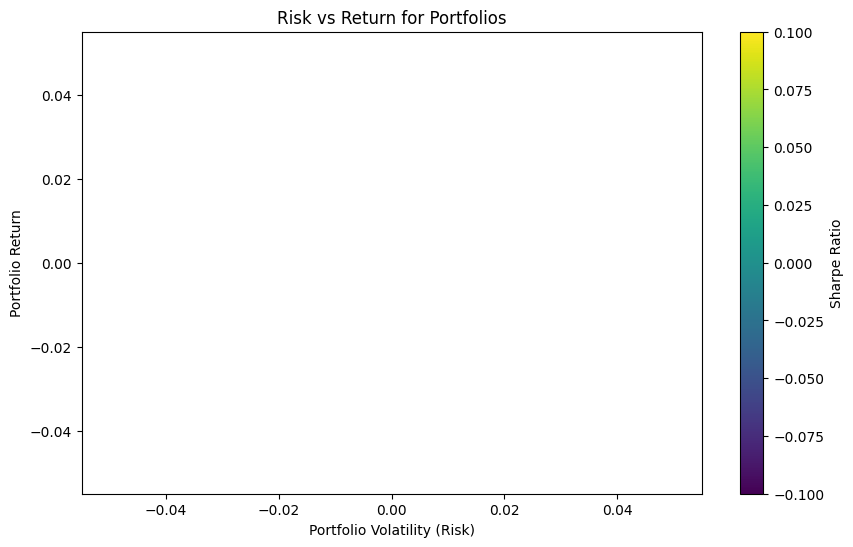

In [33]:
import matplotlib.pyplot as plt

# Simulate 10,000 portfolios to analyze the risk-return tradeoff
n_portfolios = 10000
portfolio_returns = []
portfolio_volatility = []
sharpe_ratios = []

for _ in range(n_portfolios):
    weights = np.random.random(3)
    weights /= np.sum(weights)
    
    # Portfolio performance
    port_return, port_volatility, sharpe_ratio = portfolio_performance(weights, annual_return, cov_matrix)
    
    portfolio_returns.append(port_return)
    portfolio_volatility.append(port_volatility)
    sharpe_ratios.append(sharpe_ratio)

portfolio_returns = np.array(portfolio_returns)
portfolio_volatility = np.array(portfolio_volatility)
sharpe_ratios = np.array(sharpe_ratios)

# Plot the risk-return scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(portfolio_volatility, portfolio_returns, c=sharpe_ratios, cmap='viridis', marker='o')
plt.title('Risk vs Return for Portfolios')
plt.xlabel('Portfolio Volatility (Risk)')
plt.ylabel('Portfolio Return')
plt.colorbar(label='Sharpe Ratio')
plt.show()
